## 1. Environment Setup & Visual Configuration
Initialize the foundational Python data science libraries and establish high quality visual aesthetics using Seaborn and Matplotlib.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Configure global visual aesthetics for the project
sns.set_theme(style="white")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.figsize"] = (12, 6)

## 2. Loading Local Data
Initialize an in-memory **DuckDB** engine to ensure the notebook remains entirely self-contained and reproducible. Load the relational datasets directly from the local project directory into memory tables to eliminate external database dependencies.

In [2]:
import duckdb

# Initialize standalone, in-memory database engine
conn = duckdb.connect(database=':memory:')

print("Loading optimized Olist datasets from the local directory...")

# DuckDB reads the CSVs directly from the same folder as this notebook
conn.execute("CREATE TABLE orders AS SELECT * FROM read_csv_auto('olist_orders_dataset.csv');")
conn.execute("CREATE TABLE order_items AS SELECT * FROM read_csv_auto('olist_order_items_dataset.csv');")
conn.execute("CREATE TABLE products AS SELECT * FROM read_csv_auto('olist_products_dataset.csv');")
conn.execute("CREATE TABLE order_reviews AS SELECT * FROM read_csv_auto('olist_order_reviews_dataset.csv');")
conn.execute("CREATE TABLE customers AS SELECT * FROM read_csv_auto('olist_customers_dataset.csv');")
conn.execute("CREATE TABLE order_payments AS SELECT * FROM read_csv_auto('olist_order_payments_dataset.csv');")

# Load supporting files
conn.execute("CREATE TABLE sellers AS SELECT * FROM read_csv_auto('olist_sellers_dataset.csv');")
conn.execute("CREATE TABLE category_translation AS SELECT * FROM read_csv_auto('product_category_name_translation.csv');")

print("All core tables successfully loaded!")

Loading optimized Olist datasets from the local directory...
All core tables successfully loaded!


## 3. Operational Baseline: Monthly Revenue & Order Volumes
Execute a relational SQL query aggregating total revenue and order volume grouped chronologically by month to establish the baseline growth trend of the business.

In [3]:
# SQL Query: Extracting Monthly Metrics
query_baseline = """
SELECT 
    STRFTIME('%Y-%m', CAST(o.order_purchase_timestamp AS TIMESTAMP)) AS order_month,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    COUNT(DISTINCT o.order_id) AS total_orders
FROM orders AS o
INNER JOIN order_items AS oi 
    ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY order_month
ORDER BY order_month;
"""

# Execute query and assign directly to a Pandas DataFrame
df_baseline = conn.execute(query_baseline).fetchdf()

# Display the resulting dataset structure
df_baseline

,order_month,total_revenue,total_orders
0,2016-09,134.97,1
1,2016-10,40325.11,265
2,2016-12,10.90,1
3,2017-01,111798.36,750
4,2017-02,234223.40,1653
5,2017-03,359198.85,2546
6,2017-04,340669.68,2303
7,2017-05,489338.25,3546
8,2017-06,421923.37,3135
9,2017-07,481604.52,3872


## 4. Visualizing Monthly Trends
Generate a dual-axis line chart tracking total monthly revenue and order volume to visually analyze business growth trends over time.

C:\Users\Onyeka\AppData\Local\Temp\ipykernel_22304\4247751873.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_baseline['order_month'], rotation=45, ha='right')


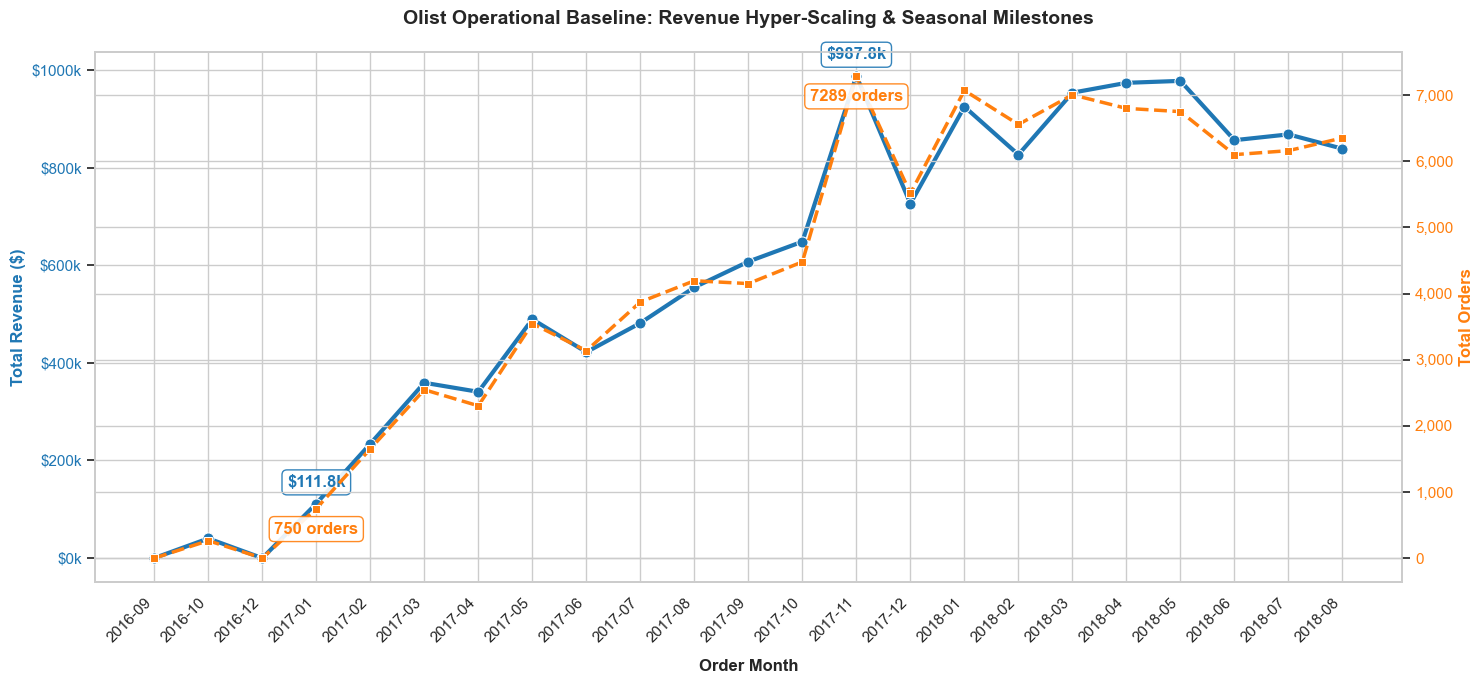

In [4]:
# Set style
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(15, 7))

# 1. Plot Revenue (Left Axis)
color_rev = '#1f77b4'
ax1.set_xlabel('Order Month', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylabel('Total Revenue ($)', color=color_rev, fontsize=12, fontweight='bold')
sns.lineplot(data=df_baseline, x='order_month', y='total_revenue', ax=ax1, color=color_rev, linewidth=3, marker='o', markersize=8)
ax1.tick_params(axis='y', labelcolor=color_rev)
ax1.set_xticklabels(df_baseline['order_month'], rotation=45, ha='right')

# --- FIX: Force regular numbers and add 'k' for thousands ---
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"${int(x/1000)}k"))

# 2. Plot Orders (Right Axis)
ax2 = ax1.twinx()
color_ord = '#ff7f0e'
ax2.set_ylabel('Total Orders', color=color_ord, fontsize=12, fontweight='bold')
sns.lineplot(data=df_baseline, x='order_month', y='total_orders', ax=ax2, color=color_ord, linewidth=2.5, marker='s', markersize=6, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color_ord)

# --- FIX: Format order counts with commas (e.g., 6,000 instead of 6000) ---
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x):,}"))

# 3. Add Explicit Milestone Labels
months = df_baseline['order_month'].tolist()
milestones = {
    '2017-01': ('$111.8k', 750),
    '2017-11': ('$987.8k', 7289)
}

for month, (rev_label, ord_label) in milestones.items():
    if month in months:
        idx = months.index(month)
        row = df_baseline.iloc[idx]
        
        # Label Revenue Point
        ax1.annotate(f"{rev_label}", 
                     xy=(idx, row['total_revenue']),
                     xytext=(0, 12), textcoords='offset points', ha='center',
                     fontweight='bold', color=color_rev,
                     bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color_rev, lw=1, alpha=0.9))
        
        # Label Order Point
        ax2.annotate(f"{ord_label} orders", 
                     xy=(idx, row['total_orders']),
                     xytext=(0, -18), textcoords='offset points', ha='center',
                     fontweight='bold', color=color_ord,
                     bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color_ord, lw=1, alpha=0.9))

plt.title('Olist Operational Baseline: Revenue Hyper-Scaling & Seasonal Milestones', fontsize=14, fontweight='bold', pad=20)
fig.tight_layout()
plt.show()

## 5. Part 1 Executive Insights: Growth & Seasonality
* **Hyper-Scaling Trend:** The platform experienced massive growth throughout 2017, with gross monthly revenue expanding from $111.8k in January (2017-01) to a peak of $987.8k in November (2017-11)—an 8.8x scaling achievement within an 11-month window.
* **November 2017 Volumetric Spike:** Fulfilling a project-peak 7,289 orders generating $987.8k in revenue. Given that this massive anomaly occurs precisely in late November, this is highly correlated with standard retail Black Friday seasonal performance rather than just the business naturally getting bigger over time.
* **Operational Stabilization:** Throughout 2018, the business stopped its rapid early growth and settled into a steady routine, consistently pulling in around $830k–$970k in monthly revenue and handling a predictable 6,000–7,000 completed orders each month.

## 6. Delivery Performance & Customer Satisfaction
Analyze the operational fulfillment timeline by calculating the actual shipping duration (in days) and evaluate its impact on customer review scores.

In [5]:
# SQL Query: Calculate delivery days and pull review scores
query_delivery = """
SELECT 
    o.order_id,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    -- Calculate the exact days taken to deliver the order
    DATE_PART('day', CAST(o.order_delivered_customer_date AS TIMESTAMP) - CAST(o.order_purchase_timestamp AS TIMESTAMP)) AS delivery_days,
    r.review_score
FROM orders o
INNER JOIN order_reviews r 
    ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL;
"""

# Execute the query and load it into a new DataFrame
df_delivery = conn.execute(query_delivery).fetchdf()

# Display a quick summary of the new dataset
df_delivery.describe()

,order_purchase_timestamp,order_delivered_customer_date,delivery_days,review_score
count,96353,96353,96353.000000,96353.000000
mean,2018-01-01 18:58:26.785445,2018-01-14 07:31:22.689496,12.058472,4.155688
min,2016-09-15 12:16:38,2016-10-11 13:46:32,0.000000,1.000000
25%,2017-09-13 21:37:44,2017-09-25 20:37:14,6.000000,4.000000
50%,2018-01-20 17:06:24,2018-02-02 17:41:43,10.000000,5.000000
75%,2018-05-05 15:59:52,2018-05-15 21:08:50,15.000000,5.000000
max,2018-08-29 15:00:37,2018-10-17 13:22:46,208.000000,5.000000
std,NaN,NaN,9.462698,1.284979


In [6]:
# Group by review score to see the average shipping days for each rating
df_score_analysis = df_delivery.groupby('review_score')['delivery_days'].mean().reset_index()

# Rename columns for clarity
df_score_analysis.columns = ['Review Score', 'Average Delivery Days']

# Print the table cleanly
df_score_analysis

,Review Score,Average Delivery Days
0,1,20.849973
1,2,16.194832
2,3,13.793242
3,4,11.848054
4,5,10.224154


## 7. Visualizing the Impact of Delivery Delays on Ratings
Create a bar chart to compare the average delivery duration against each customer review score level.

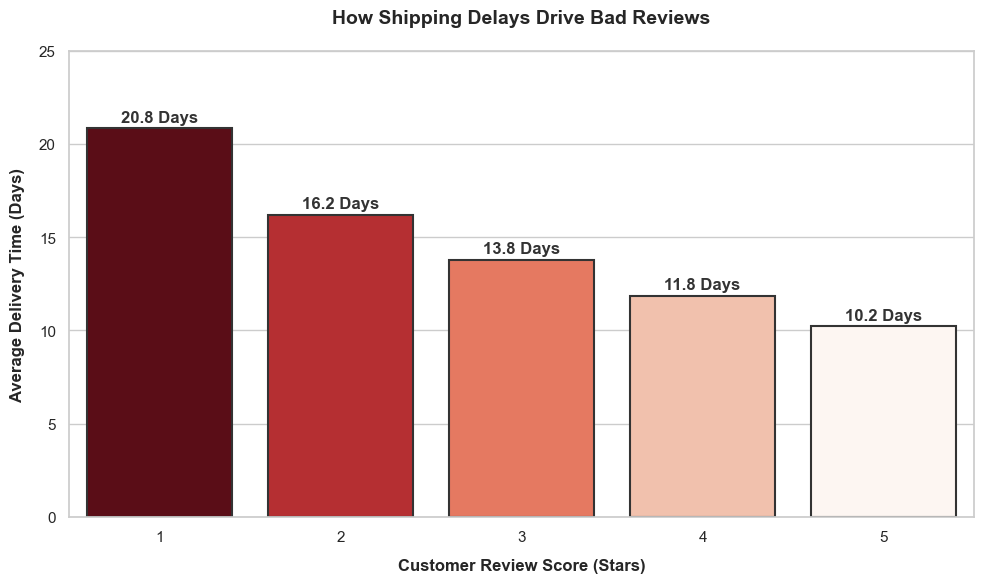

In [7]:
# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Using a distinct 'Reds_r' palette with a dark gray edge border for sharp contrast
ax = sns.barplot(
    data=df_score_analysis, 
    x='Review Score', 
    y='Average Delivery Days', 
    palette='Reds_r', # High-contrast red gradient (Dark Red = 1 Star, Light Pink = 5 Stars)
    hue='Review Score',
    legend=False,
    edgecolor='#333333', # Crisp, dark boundary line around every bar to prevent background overlap
    linewidth=1.5
)

# Add exact day labels on top of each bar
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f} Days", 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', 
        xytext=(0, 8), 
        textcoords='offset points', 
        fontweight='bold', 
        color='#333333'
    )

# Formatting labels and titles cleanly
plt.xlabel('Customer Review Score (Stars)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Average Delivery Time (Days)', fontsize=12, fontweight='bold', labelpad=10)
plt.title('How Shipping Delays Drive Bad Reviews', fontsize=14, fontweight='bold', pad=20)

# Clean up layout and display
plt.ylim(0, 25) 
plt.tight_layout()
plt.show()

## 8. Part 2 Executive Insights: Delivery Performance & Customer Satisfaction
* **The 10-Day Threshold for Excellence:** Customers who rate their experience a perfect 5 stars receive their orders in an average of 10.2 days. This establishes ~10 days as the target operational standard for high customer satisfaction.
* **The Cost of Delays:** As delivery times drag out, satisfaction drops in a predictable, step-by-step pattern. Once the average shipping time crosses two weeks (13.8 days), ratings drop to 3 stars, and when it stretches to nearly three weeks (20.8 days), it results in systemic 1-star reviews.
* **Clear Operational Bottleneck:** The data proves that poor review scores are heavily tied to slow shipping speeds rather than random customer complaints, signaling a clear need to optimize fulfillment partnerships and logistics routes.

## 9. Product Category Performance Analysis
Analyze sales performance across different product categories to identify top revenue drivers and evaluate their respective customer satisfaction levels.

In [8]:
# SQL Query: Aggregate revenue, order volume, and review scores by English product category
query_products = """
SELECT 
    t.product_category_name_english AS product_category,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(AVG(r.review_score), 2) AS average_review_score
FROM orders AS o
INNER JOIN order_items AS oi 
    ON o.order_id = oi.order_id
INNER JOIN products AS p 
    ON oi.product_id = p.product_id
INNER JOIN category_translation AS t 
    ON p.product_category_name = t.product_category_name
INNER JOIN order_reviews AS r 
    ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
GROUP BY t.product_category_name_english
ORDER BY total_revenue DESC
LIMIT 10;
"""

# Execute the query and load it into a DataFrame
df_products = conn.execute(query_products).fetchdf()

# Display the table 
df_products

,product_category,total_revenue,total_orders,average_review_score
0,health_beauty,1228986.81,8601,4.19
1,watches_gifts,1160289.57,5454,4.07
2,bed_bath_table,1027333.65,9177,3.92
3,sports_leisure,954296.99,7486,4.17
4,computers_accessories,892279.63,6499,3.98
5,furniture_decor,712414.53,6260,3.95
6,housewares,613843.72,5709,4.11
7,cool_stuff,605088.81,3531,4.19
8,auto,572750.14,3792,4.12
9,garden_tools,468477.18,3428,4.08


In [9]:
# Create a clean working copy of the dataset
df_products_clean = df_products.copy()

# Category mapping for presentation labels
category_map = {
    'health_beauty': 'Health & Beauty',
    'watches_gifts': 'Watches & Gifts',
    'bed_bath_table': 'Bed, Bath, & Table'
}

# Overwrite the original column with clean labels
df_products_clean['product_category'] = (
    df_products_clean['product_category']
    .map(category_map)
    .fillna(
        df_products_clean['product_category']
        .str.replace('_', ' ', regex=False)
        .str.title()
    )
)

df_products_clean

,product_category,total_revenue,total_orders,average_review_score
0,Health & Beauty,1228986.81,8601,4.19
1,Watches & Gifts,1160289.57,5454,4.07
2,"Bed, Bath, & Table",1027333.65,9177,3.92
3,Sports Leisure,954296.99,7486,4.17
4,Computers Accessories,892279.63,6499,3.98
5,Furniture Decor,712414.53,6260,3.95
6,Housewares,613843.72,5709,4.11
7,Cool Stuff,605088.81,3531,4.19
8,Auto,572750.14,3792,4.12
9,Garden Tools,468477.18,3428,4.08


## 10. Visualizing Top 10 Product Categories by Revenue
Create a horizontal bar chart to showcase the highest revenue-generating product categories on the platform.

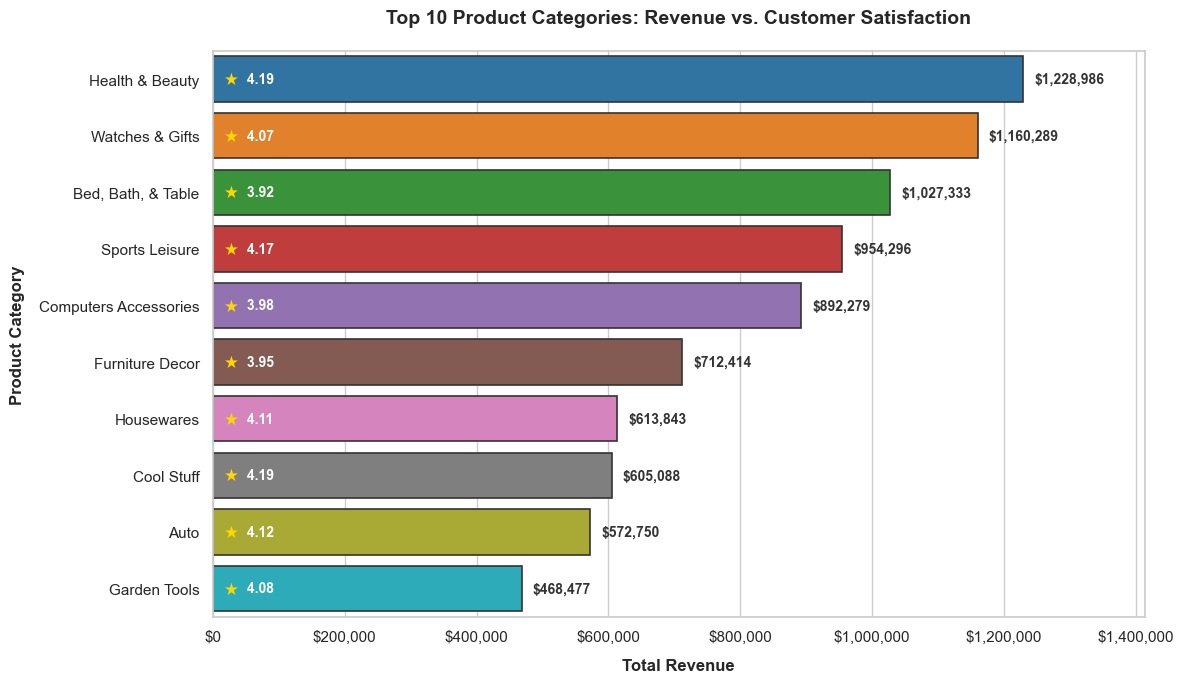

In [10]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import matplotlib.ticker as ticker

# Ensure Unicode characters like ★ render properly
mpl.rcParams['font.family'] = 'DejaVu Sans'

# Set style
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

# Create the horizontal bar plot with distinct colors using the cleaned dataframe
sns.barplot(
    data=df_products_clean,
    x='total_revenue',
    y='product_category',
    palette='tab10',
    hue='product_category',
    legend=False,
    edgecolor='#333333',
    linewidth=1.2,
    ax=ax
)

# Loop through each bar to place labels
for i, p in enumerate(ax.patches):
    width = p.get_width()
    rating = df_products_clean.iloc[i]['average_review_score']

    # 1. REVENUE LABEL
    ax.annotate(
        f"${int(width):,}",
        (width, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        xytext=(8, 0),
        textcoords='offset points',
        fontweight='bold',
        color='#333333',
        fontsize=10
    )

    # 2. RATING LABEL
    star_text = "★"
    rating_text = f" {rating:.2f}"

    # Draw yellow star
    ax.annotate(
        star_text,
        (0, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        xytext=(8, 0),
        textcoords='offset points',
        fontweight='bold',
        color='#FFD700',
        fontsize=12,
        fontname='DejaVu Sans'
    )

    # Draw white rating text slightly after the star
    ax.annotate(
        rating_text,
        (0, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        xytext=(22, 0),
        textcoords='offset points',
        fontweight='bold',
        color='white',
        fontsize=10
    )

# Axis labels and title
ax.set_xlabel('Total Revenue', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Product Category', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Top 10 Product Categories: Revenue vs. Customer Satisfaction', fontsize=14, fontweight='bold', pad=20)

# Add headroom for revenue labels
ax.set_xlim(0, df_products_clean['total_revenue'].max() * 1.15)

# Format x-axis labels with commas
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"${int(x):,}"))

plt.tight_layout()
plt.show()

## 11. Part 3 Executive Insights: Product Performance
* **The Revenue Powerhouses:** Health & Beauty and Watches & Gifts are the platform's leading financial drivers, combining for over $2.3 Million in total sales. Both categories maintain healthy satisfaction levels above a 4.0-star average.This indicates these categories have strong product-market fit, making them the safest targets for increased marketing spend and promotional campaigns for growth acceleration
* **The Volume vs. Satisfaction Risk:** The Bed, Bath, & Table category is a major operational risk. While it ranks third in total revenue ($1.02 Million) and holds the highest order volume on the platform (9,177 orders), it also holds the lowest average review score at 3.92 stars. 
* **Strategic Focus Area:** Because Bed, Bath, & Table brings in massive revenue but has the lowest customer satisfaction, management needs to investigate why these buyers are unhappy. By checking if the issue is poor product quality from top sellers or slow shipping times, the company can fix the problems before customers stop buying from the platform completely.